In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Add your Kaggle API token here (do not hardcode — use Colab Secrets or env var)
# In Colab: Secrets panel (key icon) → add KAGGLE_KEY
import os
token = os.environ.get("KAGGLE_KEY", "")
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(token)
os.chmod('/root/.kaggle/access_token', 0o600)

!pip install kaggle -q

In [ ]:
!kaggle datasets download -d gpiosenka/70-dog-breedsimage-data-set --unzip -p /content/data
print(os.listdir('/content/data'))

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/70-dog-breedsimage-data-set
License(s): CC0-1.0
100% 215M/215M [00:02<00:00, 110MB/s] 

['train', 'valid', 'dogs.csv', 'test']


In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder('/content/data/train', transform=transform)
val_data   = datasets.ImageFolder('/content/data/valid', transform=transform)
test_data  = datasets.ImageFolder('/content/data/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print(f'Classes: {len(train_data.classes)}')
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Classes: 70
Train: 7946 | Val: 700 | Test: 700


In [ ]:
# Model: ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 70)
model = model.to(device)

print(model.fc)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Linear(in_features=2048, out_features=70, bias=True)
Trainable parameters: 143,430


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 15
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

print('Training complete!')

Epoch [1/15] Train Loss: 1.7825 | Val Loss: 0.8214
Epoch [2/15] Train Loss: 0.5101 | Val Loss: 0.5446
Epoch [3/15] Train Loss: 0.3279 | Val Loss: 0.4808
Epoch [4/15] Train Loss: 0.2384 | Val Loss: 0.4336
Epoch [5/15] Train Loss: 0.1826 | Val Loss: 0.4303
Epoch [6/15] Train Loss: 0.1545 | Val Loss: 0.4243
Epoch [7/15] Train Loss: 0.1225 | Val Loss: 0.4144
Epoch [8/15] Train Loss: 0.1085 | Val Loss: 0.4127
Epoch [9/15] Train Loss: 0.0898 | Val Loss: 0.4132
Epoch [10/15] Train Loss: 0.0744 | Val Loss: 0.4207
Epoch [11/15] Train Loss: 0.0692 | Val Loss: 0.4239
Epoch [12/15] Train Loss: 0.0599 | Val Loss: 0.4293
Epoch [13/15] Train Loss: 0.0521 | Val Loss: 0.4276
Epoch [14/15] Train Loss: 0.0493 | Val Loss: 0.4263
Epoch [15/15] Train Loss: 0.0428 | Val Loss: 0.4343
Training complete!


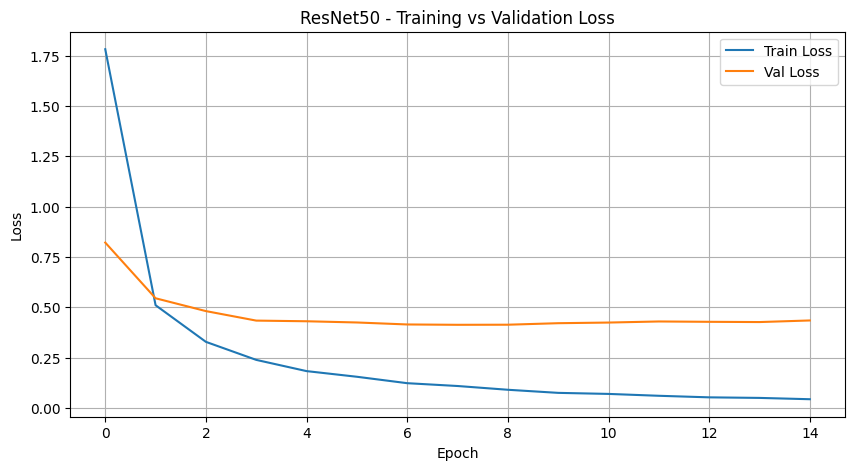

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 - Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')

Accuracy:  0.9614
Precision: 0.9630
Recall:    0.9614
F1 Score:  0.9609


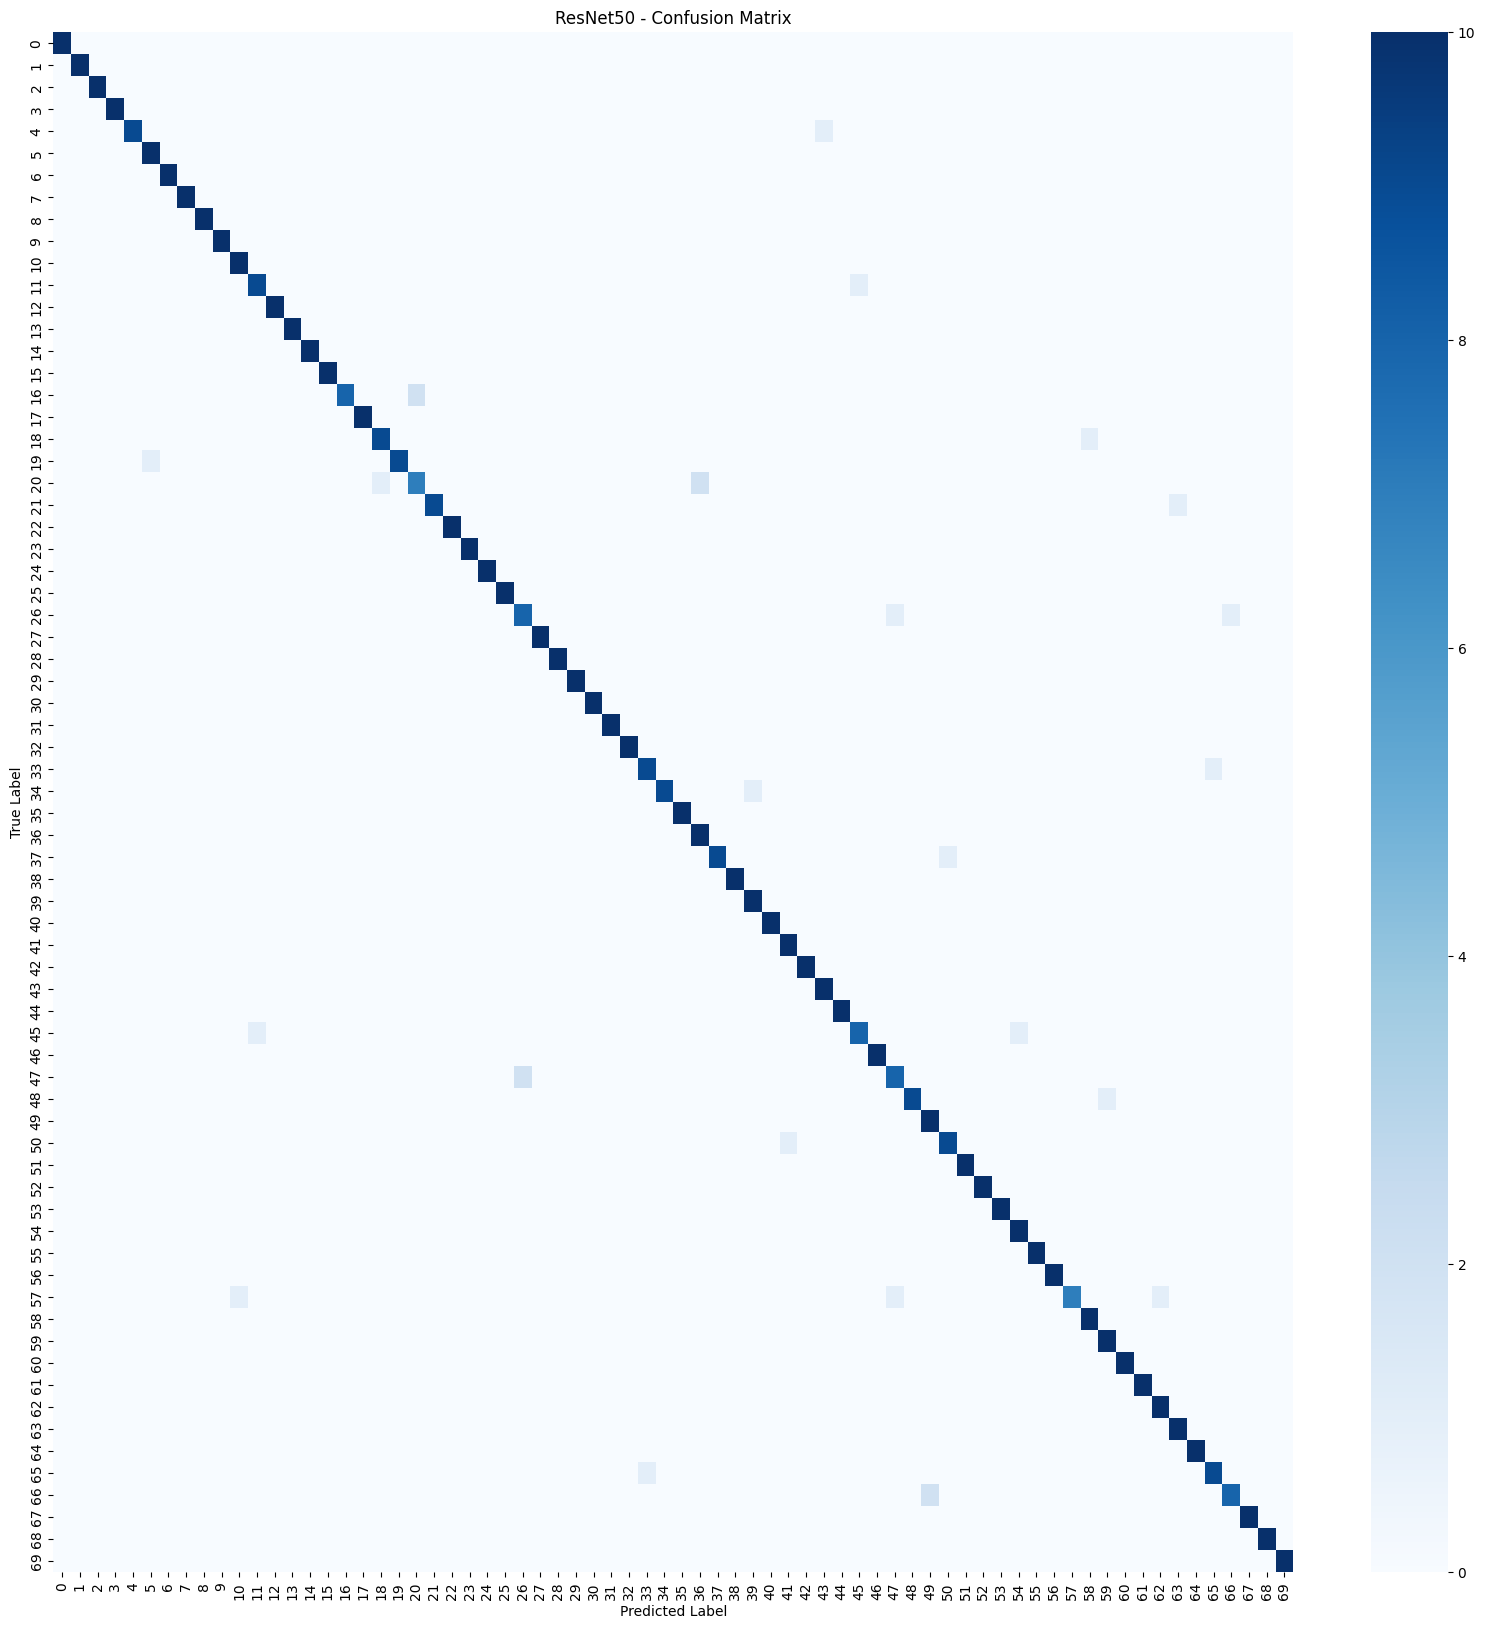

In [ ]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('ResNet50 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()